
# Water Potability — Estudio especializado de `PauliFeatureMap`

Este notebook continúa con los **64 ejemplos reales y los cuatro folds congelados** de la etapa clásica. Se concentra exclusivamente en mapas de características de Pauli construidos con Qiskit.

## Objetivos

1. Construir estados $|\phi(x)\rangle$ mediante `pauli_feature_map()`.
2. Calcular explícitamente el kernel de fidelidad
   $$K_{ij}=|\langle\phi(x_i)|\phi(x_j)\rangle|^2.$$
3. Entrenar `sklearn.svm.SVC(kernel="precomputed")`.
4. Estudiar cómo cambian la geometría y la clasificación al variar:
   - términos de Pauli de uno y dos qubits;
   - repeticiones o recarga de datos;
   - entrelazamiento lineal, circular y completo;
   - factor de rotación `alpha`;
   - escalado angular de las variables.
5. Evaluar exactitud, exactitud balanceada, F1, alineación kernel–objetivo, similitud intra/interclase, espectro, rango efectivo, profundidad, compuertas de dos qubits, shots, ruido y tiempo.

## Regla metodológica

En cada fold externo, la imputación y el escalado se ajustan **solo con las 48 muestras de entrenamiento**. Las 16 muestras de validación no intervienen en esos ajustes. El parámetro clásico `C` se elige mediante validación interna usando únicamente el kernel de entrenamiento.

La comparación entre muchos mapas sobre los mismos cuatro folds es un **estudio exploratorio de arquitectura**. El mapa con mayor F1 medio no debe presentarse como una estimación final totalmente independiente sin una capa adicional de validación o un conjunto externo.

## Número de qubits

Se emplean **9 qubits**, uno por cada variable fisicoquímica original. El espacio de estados tiene dimensión $2^9=512$, pero el SVC recibe únicamente las fidelidades entre pares de estados.


In [1]:

# 1. Drive, instalación reproducible e importaciones
import sys
import subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'qiskit==2.2.3',
    'qiskit-aer==0.17.2',
    'pylatexenc'
], check=True)

import json
import hashlib
import time
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

from qiskit import QuantumCircuit
from qiskit.circuit.library import pauli_feature_map
from qiskit.quantum_info import Statevector
from qiskit.transpiler import CouplingMap, generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

warnings.filterwarnings('ignore', category=FutureWarning)
np.set_printoptions(precision=4, suppress=True)

SEED = 42
NUM_QUBITS = 9
C_GRID = (0.01, 0.1, 1.0, 10.0, 100.0)
QUICK_MODE = False
RUN_SHOT_STUDY = True
RUN_NOISE_STUDY = True
SHOT_LEVELS = (128, 512, 2048)
SHOT_REPEATS = 5
NOISE_SHOTS = 512
NOISE_PAIRS_PER_MAP = 8

if IN_COLAB:
    BASE_DIR = Path('/content/drive/MyDrive/Colab Notebooks')
else:
    BASE_DIR = Path('/mnt/data')

DATA_DIR = BASE_DIR / 'artifacts_qsvm_input_v2'
ARTIFACT_DIR = BASE_DIR / 'artifacts_pauli_feature_map_v1'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('Qubits:', NUM_QUBITS)
print('Dimensión de Hilbert:', 2 ** NUM_QUBITS)
print('Artifacts:', ARTIFACT_DIR)


Mounted at /content/drive
Qubits: 9
Dimensión de Hilbert: 512
Artifacts: /content/drive/MyDrive/Colab Notebooks/artifacts_pauli_feature_map_v1


In [14]:

# 2. Carga y validación de las 64 muestras y folds congelados
raw_candidates = [
    DATA_DIR / 'qsvm_64_raw.csv',
    BASE_DIR / 'qsvm_64_raw.csv',
    BASE_DIR / 'svm64_training_raw.csv',
]
fold_candidates = [
    DATA_DIR / 'qsvm_64_folds.csv',
    BASE_DIR / 'qsvm_64_folds.csv',
    BASE_DIR / 'svm64_fixed_cv_folds.csv',
]

raw_path = next((p for p in raw_candidates if p.exists()), None)
fold_path = next((p for p in fold_candidates if p.exists()), None)
if raw_path is None or fold_path is None:
    raise FileNotFoundError('No se encontraron qsvm_64_raw.csv y qsvm_64_folds.csv.')

raw64 = pd.read_csv(raw_path)
folds64 = pd.read_csv(fold_path)

FEATURES = [
    'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
    'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity'
]
TARGET = 'Potability'

assert raw64.shape[0] == 64
assert raw64[TARGET].value_counts().to_dict() == {0: 32, 1: 32}
assert set(folds64['validation_fold'].unique()) == {0, 1, 2, 3}
assert raw64['source_index'].tolist() == folds64['source_index'].tolist()
assert raw64[TARGET].tolist() == folds64[TARGET].tolist()
assert len(FEATURES) == NUM_QUBITS

X_raw = raw64[FEATURES].to_numpy(dtype=float)
y = raw64[TARGET].to_numpy(dtype=int)
validation_fold = folds64['validation_fold'].to_numpy(dtype=int)

fold_summary = (
    folds64.groupby(['validation_fold', TARGET])
    .size().unstack(fill_value=0)
    .rename(columns={0: 'class_0', 1: 'class_1'})
)
fold_summary['validation_size'] = fold_summary.sum(axis=1)
fold_summary['training_size'] = 64 - fold_summary['validation_size']

display(fold_summary)
display(raw64[FEATURES].isna().sum().to_frame('missing'))


Potability,class_0,class_1,validation_size,training_size
validation_fold,,,,
0,8,8,16,48
1,8,8,16,48
2,8,8,16,48
3,8,8,16,48


,missing
ph,6
Hardness,0
Solids,0
Chloramines,0
Sulfate,10
Conductivity,0
Organic_carbon,0
Trihalomethanes,3
Turbidity,0



## Mapa de Pauli

El mapa implementa evoluciones de la forma

$$
U_{\Phi(x)}=\exp\left(i\sum_{S\in\mathcal I}\phi_S(x)\prod_{j\in S}P_j\right),
$$

donde $P_j\in\{I,X,Y,Z\}$. Los términos de un qubit controlan rotaciones locales; cadenas como `XX`, `YY`, `ZY` o `ZZ` introducen interacciones entre qubits según la topología elegida.

La función moderna `pauli_feature_map()` devuelve directamente un `QuantumCircuit`. En este notebook se evita la clase antigua `PauliFeatureMap` para mantener compatibilidad futura.


In [3]:

# 3. Preprocesamiento angular, construcción del mapa y kernel exacto
@dataclass
class AnglePreprocessor:
    mode: str = 'minmax'

    def fit(self, X):
        self.imputer_ = SimpleImputer(strategy='median')
        Xi = self.imputer_.fit_transform(X)
        if self.mode == 'minmax':
            self.scaler_ = MinMaxScaler(feature_range=(0.0, np.pi)).fit(Xi)
        elif self.mode in {'stdclip', 'atan'}:
            self.scaler_ = StandardScaler().fit(Xi)
        else:
            raise ValueError(f'Modo no soportado: {self.mode}')
        return self

    def transform(self, X):
        Xi = self.imputer_.transform(X)
        Z = self.scaler_.transform(Xi)
        if self.mode == 'minmax':
            return np.clip(Z, 0.0, np.pi)
        if self.mode == 'stdclip':
            Z = np.clip(Z, -3.0, 3.0)
            return (Z + 3.0) * np.pi / 6.0
        return np.arctan(Z) + np.pi / 2.0

    def fit_transform(self, X):
        return self.fit(X).transform(X)


def build_feature_map(config):
    return pauli_feature_map(
        feature_dimension=NUM_QUBITS,
        reps=int(config['reps']),
        entanglement=config['entanglement'],
        alpha=float(config['alpha']),
        paulis=list(config['paulis']),
        insert_barriers=False,
        name=config['name'],
    )


def ordered_feature_parameters(feature_map):
    def parameter_index(parameter):
        name = parameter.name
        if '[' in name and ']' in name:
            return int(name.split('[')[1].split(']')[0])
        return name
    return sorted(feature_map.parameters, key=parameter_index)


def state_matrix(feature_map, X_angles):
    params = ordered_feature_parameters(feature_map)
    if len(params) != X_angles.shape[1]:
        raise ValueError('El número de parámetros del circuito no coincide con las características.')
    states = []
    for row in X_angles:
        bound = feature_map.assign_parameters(dict(zip(params, row)), inplace=False)
        states.append(Statevector.from_instruction(bound).data)
    return np.asarray(states, dtype=complex)


def fidelity_kernel_from_states(A, B=None):
    if B is None:
        B = A
    overlaps = A.conj() @ B.T
    return np.clip((np.abs(overlaps) ** 2).real, 0.0, 1.0)


def exact_kernel(feature_map, X_left, X_right=None):
    A = state_matrix(feature_map, X_left)
    B = A if X_right is None else state_matrix(feature_map, X_right)
    K = fidelity_kernel_from_states(A, B)
    if X_right is None:
        K = (K + K.T) / 2.0
        np.fill_diagonal(K, 1.0)
    return K


def binary_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }


def centered_kernel_alignment(K, labels):
    n = len(labels)
    H = np.eye(n) - np.ones((n, n)) / n
    y_pm = 2 * np.asarray(labels) - 1
    Y = np.outer(y_pm, y_pm)
    Kc = H @ K @ H
    Yc = H @ Y @ H
    denominator = np.linalg.norm(Kc, 'fro') * np.linalg.norm(Yc, 'fro')
    return float(np.sum(Kc * Yc) / denominator) if denominator > 0 else np.nan


def similarity_summary(K, labels):
    labels = np.asarray(labels)
    upper = np.triu_indices_from(K, k=1)
    same = labels[upper[0]] == labels[upper[1]]
    values = K[upper]
    intra = float(values[same].mean())
    inter = float(values[~same].mean())
    return intra, inter, intra - inter


def spectral_summary(K, tolerance=1e-12):
    eigenvalues = np.linalg.eigvalsh((K + K.T) / 2.0)
    eigenvalues = np.clip(eigenvalues, 0.0, None)
    positive = eigenvalues[eigenvalues > tolerance]
    if positive.size == 0:
        effective_rank = 0.0
    else:
        probabilities = positive / positive.sum()
        effective_rank = float(np.exp(-(probabilities * np.log(probabilities)).sum()))
    return effective_rank, eigenvalues


def kernel_concentration(K):
    n = len(K)
    upper_values = K[np.triu_indices(n, k=1)]
    identity_distance = float(np.linalg.norm(K - np.eye(n), 'fro') / np.linalg.norm(np.eye(n), 'fro'))
    uniform = np.ones_like(K)
    uniform_distance = float(np.linalg.norm(K - uniform, 'fro') / np.linalg.norm(uniform, 'fro'))
    return {
        'offdiag_mean': float(upper_values.mean()),
        'offdiag_std': float(upper_values.std()),
        'distance_to_identity': identity_distance,
        'distance_to_uniform': uniform_distance,
    }


def choose_c_inner(K_train, y_train, seed):
    inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    rows = []
    for C in C_GRID:
        scores = []
        for tr, va in inner.split(np.zeros(len(y_train)), y_train):
            model = SVC(kernel='precomputed', C=C)
            model.fit(K_train[np.ix_(tr, tr)], y_train[tr])
            pred = model.predict(K_train[np.ix_(va, tr)])
            scores.append(f1_score(y_train[va], pred, zero_division=0))
        rows.append({'C': C, 'mean_inner_f1': float(np.mean(scores))})
    best = max(rows, key=lambda item: (item['mean_inner_f1'], -item['C']))
    return float(best['C']), rows


In [4]:

# 4. Configuraciones de PauliFeatureMap
BASELINE_NAME = 'P_Z_ZZ_r1_linear_a2_minmax'

MAP_CONFIGS = [
    # Ablación de términos de Pauli.
    dict(name='P_Z_r1_linear_a2_minmax', paulis=('Z',), reps=1, entanglement='linear', alpha=2.0, scaling='minmax', group='pauli_terms'),
    dict(name='P_ZZ_r1_linear_a2_minmax', paulis=('ZZ',), reps=1, entanglement='linear', alpha=2.0, scaling='minmax', group='pauli_terms'),
    dict(name=BASELINE_NAME, paulis=('Z', 'ZZ'), reps=1, entanglement='linear', alpha=2.0, scaling='minmax', group='baseline'),
    dict(name='P_X_XX_r1_linear_a2_minmax', paulis=('X', 'XX'), reps=1, entanglement='linear', alpha=2.0, scaling='minmax', group='pauli_terms'),
    dict(name='P_Y_YY_r1_linear_a2_minmax', paulis=('Y', 'YY'), reps=1, entanglement='linear', alpha=2.0, scaling='minmax', group='pauli_terms'),
    dict(name='P_X_Y_Z_r1_linear_a2_minmax', paulis=('X', 'Y', 'Z'), reps=1, entanglement='linear', alpha=2.0, scaling='minmax', group='pauli_terms'),
    dict(name='P_XYZ_XXYYZZ_r1_linear_a2_minmax', paulis=('X', 'Y', 'Z', 'XX', 'YY', 'ZZ'), reps=1, entanglement='linear', alpha=2.0, scaling='minmax', group='pauli_terms'),
    dict(name='P_Z_ZY_ZZ_r1_linear_a2_minmax', paulis=('Z', 'ZY', 'ZZ'), reps=1, entanglement='linear', alpha=2.0, scaling='minmax', group='pauli_terms'),

    # Recarga de datos y topología.
    dict(name='P_Z_ZZ_r2_linear_a2_minmax', paulis=('Z', 'ZZ'), reps=2, entanglement='linear', alpha=2.0, scaling='minmax', group='reps'),
    dict(name='P_Z_ZZ_r1_circular_a2_minmax', paulis=('Z', 'ZZ'), reps=1, entanglement='circular', alpha=2.0, scaling='minmax', group='entanglement'),
    dict(name='P_Z_ZZ_r1_full_a2_minmax', paulis=('Z', 'ZZ'), reps=1, entanglement='full', alpha=2.0, scaling='minmax', group='entanglement'),

    # Intensidad angular.
    dict(name='P_Z_ZZ_r1_linear_a1_minmax', paulis=('Z', 'ZZ'), reps=1, entanglement='linear', alpha=1.0, scaling='minmax', group='alpha'),
    dict(name='P_Z_ZZ_r1_linear_a4_minmax', paulis=('Z', 'ZZ'), reps=1, entanglement='linear', alpha=4.0, scaling='minmax', group='alpha'),

    # Escalado de entrada.
    dict(name='P_Z_ZZ_r1_linear_a2_stdclip', paulis=('Z', 'ZZ'), reps=1, entanglement='linear', alpha=2.0, scaling='stdclip', group='scaling'),
    dict(name='P_Z_ZZ_r1_linear_a2_atan', paulis=('Z', 'ZZ'), reps=1, entanglement='linear', alpha=2.0, scaling='atan', group='scaling'),
]

if QUICK_MODE:
    keep = {
        BASELINE_NAME,
        'P_Z_r1_linear_a2_minmax',
        'P_ZZ_r1_linear_a2_minmax',
        'P_XYZ_XXYYZZ_r1_linear_a2_minmax',
        'P_Z_ZZ_r2_linear_a2_minmax',
    }
    MAP_CONFIGS = [cfg for cfg in MAP_CONFIGS if cfg['name'] in keep]

config_by_name = {cfg['name']: cfg for cfg in MAP_CONFIGS}
display(pd.DataFrame(MAP_CONFIGS))


,name,paulis,reps,entanglement,alpha,scaling,group
0,P_Z_r1_linear_a2_minmax,"(Z,)",1,linear,2.0,minmax,pauli_terms
1,P_ZZ_r1_linear_a2_minmax,"(ZZ,)",1,linear,2.0,minmax,pauli_terms
2,P_Z_ZZ_r1_linear_a2_minmax,"(Z, ZZ)",1,linear,2.0,minmax,baseline
3,P_X_XX_r1_linear_a2_minmax,"(X, XX)",1,linear,2.0,minmax,pauli_terms
4,P_Y_YY_r1_linear_a2_minmax,"(Y, YY)",1,linear,2.0,minmax,pauli_terms
5,P_X_Y_Z_r1_linear_a2_minmax,"(X, Y, Z)",1,linear,2.0,minmax,pauli_terms
6,P_XYZ_XXYYZZ_r1_linear_a2_minmax,"(X, Y, Z, XX, YY, ZZ)",1,linear,2.0,minmax,pauli_terms
7,P_Z_ZY_ZZ_r1_linear_a2_minmax,"(Z, ZY, ZZ)",1,linear,2.0,minmax,pauli_terms
8,P_Z_ZZ_r2_linear_a2_minmax,"(Z, ZZ)",2,linear,2.0,minmax,reps
9,P_Z_ZZ_r1_circular_a2_minmax,"(Z, ZZ)",1,circular,2.0,minmax,entanglement


In [5]:

# 5. Circuito base y explicación del número de qubits
baseline_cfg = config_by_name[BASELINE_NAME]
baseline_map = build_feature_map(baseline_cfg)

print(baseline_map)
print('Paulis:', baseline_cfg['paulis'])
print('Repeticiones:', baseline_cfg['reps'])
print('Entrelazamiento:', baseline_cfg['entanglement'])
print('Alpha:', baseline_cfg['alpha'])
print('Qubits:', baseline_map.num_qubits)
print('Parámetros de datos:', len(baseline_map.parameters))
print('Dimensión del espacio de estados:', 2 ** baseline_map.num_qubits)

fig = baseline_map.draw(output='mpl', fold=120)
fig.savefig(ARTIFACT_DIR / 'pauli_baseline_circuit.png', dpi=180, bbox_inches='tight')
plt.show()


   ┌───┐┌───────────┐                                               »
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■───────»
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐     »
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├──■──»
   ├───┤├───────────┤└───┘└──────────────────────────────┘└───┘┌─┴─┐»
2: ┤ H ├┤ P(2*x[2]) ├──────────────────────────────────────────┤ X ├»
   ├───┤├───────────┤                                          └───┘»
3: ┤ H ├┤ P(2*x[3]) ├───────────────────────────────────────────────»
   ├───┤├───────────┤                                               »
4: ┤ H ├┤ P(2*x[4]) ├───────────────────────────────────────────────»
   ├───┤├───────────┤                                               »
5: ┤ H ├┤ P(2*x[5]) ├───────────────────────────────────────────────»
   ├───┤├───────────┤                                               »
6: ┤ H ├┤ P(2*x[6]) ├───────────────────────────────────────────────»
   ├───┤├───────────


## Validación cruzada con kernel precomputado

Para cada configuración y fold:

1. Se ajusta imputación y escalado en las 48 muestras de training.
2. Se preparan los statevectors de training y validation.
3. Se construyen
   $$K_{train}=|\Phi_{train}\Phi_{train}^{\dagger}|^2,$$
   $$K_{validation}=|\Phi_{validation}\Phi_{train}^{\dagger}|^2.$$
4. Se selecciona `C` con tres folds internos dentro de `K_train`.
5. Se ajusta `SVC(kernel="precomputed")` y se evalúa sobre las 16 muestras externas.


In [6]:

# 6. Validación cruzada exacta por configuración
def evaluate_config_cv(config):
    feature_map = build_feature_map(config)
    fold_rows = []
    cache = {}

    for fold in sorted(np.unique(validation_fold)):
        validation_idx = np.where(validation_fold == fold)[0]
        train_idx = np.where(validation_fold != fold)[0]

        preprocessor = AnglePreprocessor(config['scaling'])
        X_train = preprocessor.fit_transform(X_raw[train_idx])
        X_validation = preprocessor.transform(X_raw[validation_idx])
        y_train = y[train_idx]
        y_validation = y[validation_idx]

        t0 = time.perf_counter()
        train_states = state_matrix(feature_map, X_train)
        validation_states = state_matrix(feature_map, X_validation)
        state_seconds = time.perf_counter() - t0

        t1 = time.perf_counter()
        K_train = fidelity_kernel_from_states(train_states)
        K_train = (K_train + K_train.T) / 2.0
        np.fill_diagonal(K_train, 1.0)
        K_validation = fidelity_kernel_from_states(validation_states, train_states)
        kernel_seconds = time.perf_counter() - t1

        best_C, inner_scores = choose_c_inner(K_train, y_train, SEED + fold)

        t2 = time.perf_counter()
        classifier = SVC(kernel='precomputed', C=best_C)
        classifier.fit(K_train, y_train)
        prediction = classifier.predict(K_validation)
        svc_seconds = time.perf_counter() - t2

        metrics = binary_metrics(y_validation, prediction)
        intra, inter, gap = similarity_summary(K_train, y_train)
        effective_rank, _ = spectral_summary(K_train)
        concentration = kernel_concentration(K_train)
        metrics.update({
            'map': config['name'],
            'group': config['group'],
            'fold': int(fold),
            'C': best_C,
            'alignment': centered_kernel_alignment(K_train, y_train),
            'intra_similarity': intra,
            'inter_similarity': inter,
            'similarity_gap': gap,
            'effective_rank_train': effective_rank,
            **concentration,
            'state_seconds': state_seconds,
            'kernel_seconds': kernel_seconds,
            'svc_seconds': svc_seconds,
            'total_seconds': state_seconds + kernel_seconds + svc_seconds,
        })
        fold_rows.append(metrics)
        cache[int(fold)] = {
            'train_idx': train_idx,
            'validation_idx': validation_idx,
            'y_train': y_train,
            'y_validation': y_validation,
            'K_train': K_train,
            'K_validation': K_validation,
            'C': best_C,
            'inner_scores': inner_scores,
        }

    return pd.DataFrame(fold_rows), cache

all_fold_results = []
KERNEL_CACHE = {}

for number, cfg in enumerate(MAP_CONFIGS, start=1):
    print(f'[{number}/{len(MAP_CONFIGS)}] {cfg["name"]}')
    fold_df, cache = evaluate_config_cv(cfg)
    all_fold_results.append(fold_df)
    KERNEL_CACHE[cfg['name']] = cache

fold_results = pd.concat(all_fold_results, ignore_index=True)

summary_columns = [
    'accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall',
    'alignment', 'intra_similarity', 'inter_similarity', 'similarity_gap',
    'effective_rank_train', 'offdiag_mean', 'offdiag_std',
    'distance_to_identity', 'distance_to_uniform', 'total_seconds'
]
summary = fold_results.groupby(['map', 'group'])[summary_columns].agg(['mean', 'std'])
summary.columns = ['_'.join(column) for column in summary.columns]
summary = summary.reset_index().sort_values(['f1_mean', 'balanced_accuracy_mean'], ascending=False)

display(summary)
print('Mejor configuración exploratoria por F1 medio:', summary.iloc[0]['map'])


[1/15] P_Z_r1_linear_a2_minmax
[2/15] P_ZZ_r1_linear_a2_minmax
[3/15] P_Z_ZZ_r1_linear_a2_minmax
[4/15] P_X_XX_r1_linear_a2_minmax
[5/15] P_Y_YY_r1_linear_a2_minmax
[6/15] P_X_Y_Z_r1_linear_a2_minmax
[7/15] P_XYZ_XXYYZZ_r1_linear_a2_minmax
[8/15] P_Z_ZY_ZZ_r1_linear_a2_minmax
[9/15] P_Z_ZZ_r2_linear_a2_minmax
[10/15] P_Z_ZZ_r1_circular_a2_minmax
[11/15] P_Z_ZZ_r1_full_a2_minmax
[12/15] P_Z_ZZ_r1_linear_a1_minmax
[13/15] P_Z_ZZ_r1_linear_a4_minmax
[14/15] P_Z_ZZ_r1_linear_a2_stdclip
[15/15] P_Z_ZZ_r1_linear_a2_atan


,map,group,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,precision_mean,precision_std,...,offdiag_mean_mean,offdiag_mean_std,offdiag_std_mean,offdiag_std_std,distance_to_identity_mean,distance_to_identity_std,distance_to_uniform_mean,distance_to_uniform_std,total_seconds_mean,total_seconds_std
1,P_X_XX_r1_linear_a2_minmax,pauli_terms,0.500000,0.000000,0.500000,0.000000,0.666667,0.000000,0.500000,0.000000,...,1.000000,0.000000,1.110223e-16,0.000000,6.855655,0.000000,1.669868e-14,0.000000,1.582922,0.303611
14,P_Z_r1_linear_a2_minmax,pauli_terms,0.609375,0.059839,0.609375,0.059839,0.645414,0.063866,0.590593,0.046704,...,0.010440,0.001560,3.536879e-02,0.002604,0.252893,0.019563,9.798258e-01,0.001474,0.182900,0.052056
0,P_XYZ_XXYYZZ_r1_linear_a2_minmax,pauli_terms,0.609375,0.138585,0.609375,0.138585,0.629708,0.117131,0.613546,0.143759,...,0.003609,0.000132,6.797599e-03,0.000561,0.052784,0.003558,9.859804e-01,0.000129,2.685157,1.173414
4,P_ZZ_r1_linear_a2_minmax,pauli_terms,0.515625,0.128847,0.515625,0.128847,0.610814,0.075313,0.523810,0.101015,...,0.004812,0.000588,2.373910e-02,0.002597,0.166094,0.017805,9.850492e-01,0.000561,0.577476,0.180484
5,P_Z_ZY_ZZ_r1_linear_a2_minmax,pauli_terms,0.500000,0.051031,0.500000,0.051031,0.555449,0.099888,0.494444,0.036851,...,0.002604,0.000076,5.463817e-03,0.000595,0.041517,0.003798,9.869667e-01,0.000073,0.733571,0.114804
9,P_Z_ZZ_r1_linear_a2_atan,scaling,0.515625,0.106739,0.515625,0.106739,0.519697,0.138059,0.525000,0.076820,...,0.002230,0.000151,7.454060e-03,0.001581,0.053419,0.010356,9.873506e-01,0.000151,0.182504,0.006697
13,P_Z_ZZ_r2_linear_a2_minmax,reps,0.562500,0.183995,0.562500,0.183995,0.511813,0.213572,0.572619,0.219267,...,0.003009,0.000210,7.013111e-03,0.001065,0.052337,0.007263,9.865756e-01,0.000200,0.881958,0.326461
8,P_Z_ZZ_r1_linear_a1_minmax,alpha,0.515625,0.106739,0.515625,0.106739,0.510719,0.236391,0.477083,0.160349,...,0.008919,0.002046,2.863131e-02,0.004943,0.205615,0.036486,9.811214e-01,0.001893,0.183565,0.005572
2,P_X_Y_Z_r1_linear_a2_minmax,pauli_terms,0.515625,0.118311,0.515625,0.118311,0.509973,0.162957,0.505303,0.115082,...,0.027079,0.000782,4.979164e-02,0.000638,0.388607,0.003183,9.639929e-01,0.000792,0.760333,0.161312
3,P_Y_YY_r1_linear_a2_minmax,pauli_terms,0.531250,0.108253,0.531250,0.108253,0.489477,0.216694,0.504419,0.178281,...,0.002375,0.000186,6.103315e-03,0.000570,0.044903,0.004060,9.871966e-01,0.000181,1.101632,0.259358


Mejor configuración exploratoria por F1 medio: P_X_XX_r1_linear_a2_minmax


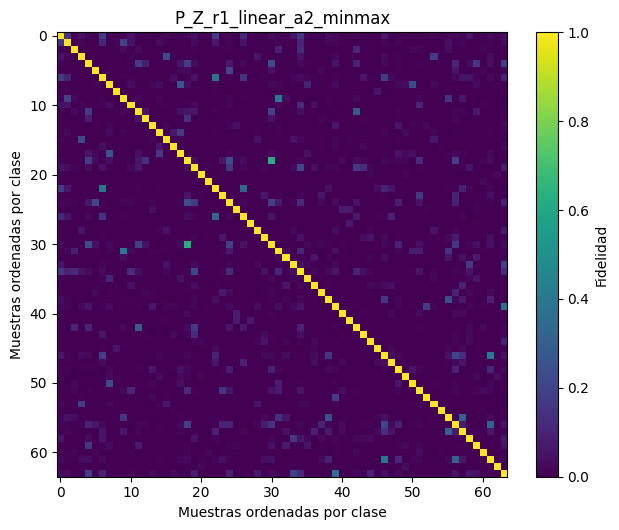

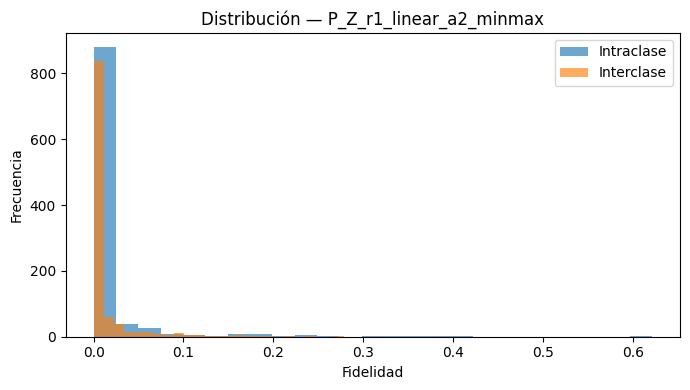

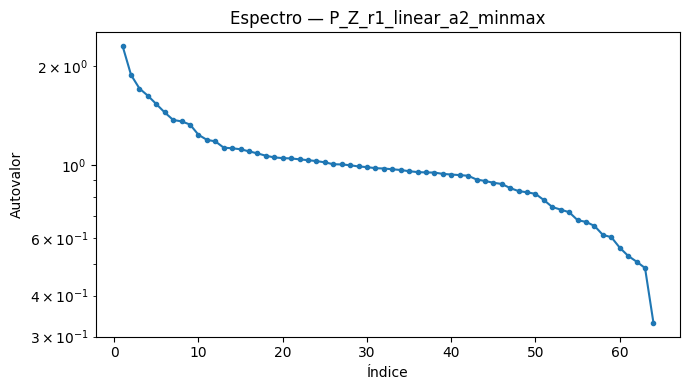

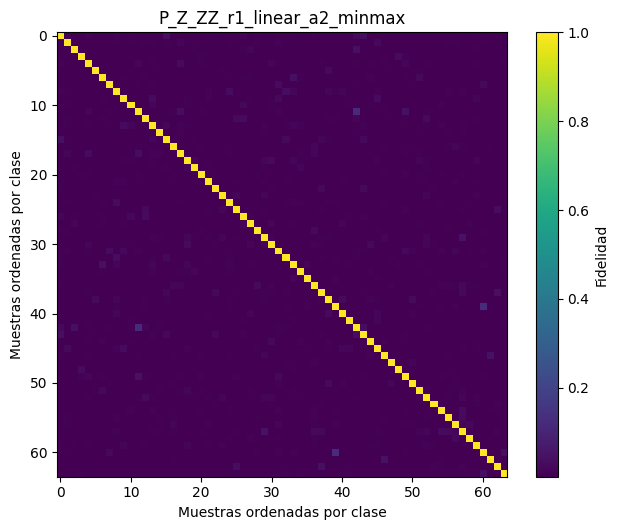

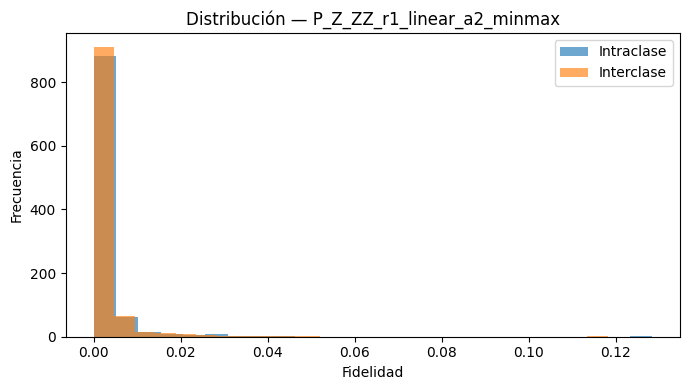

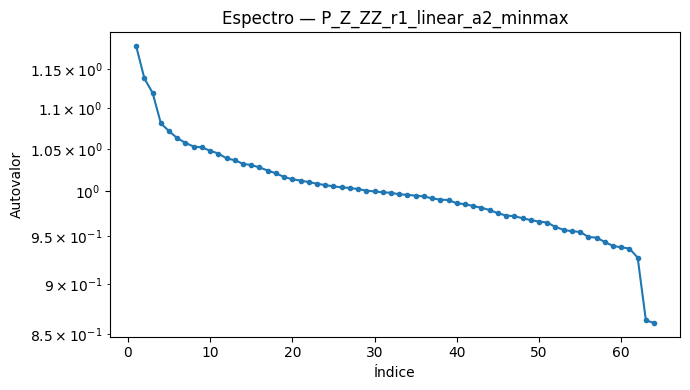

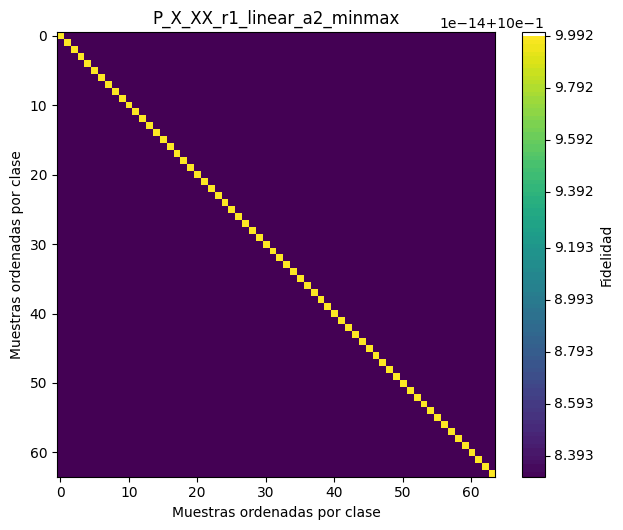

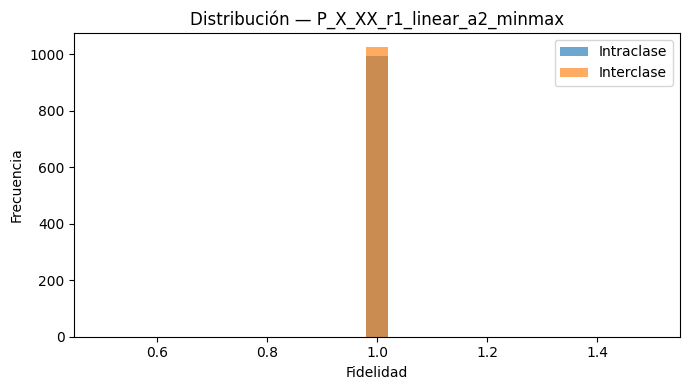

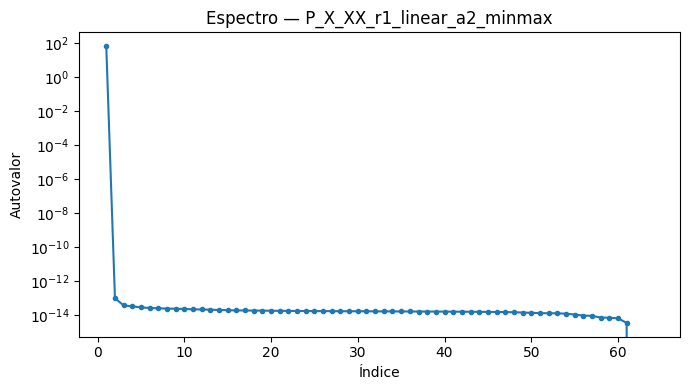

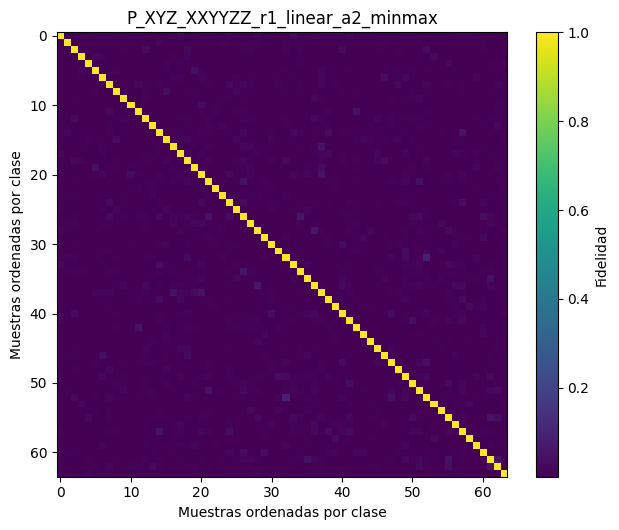

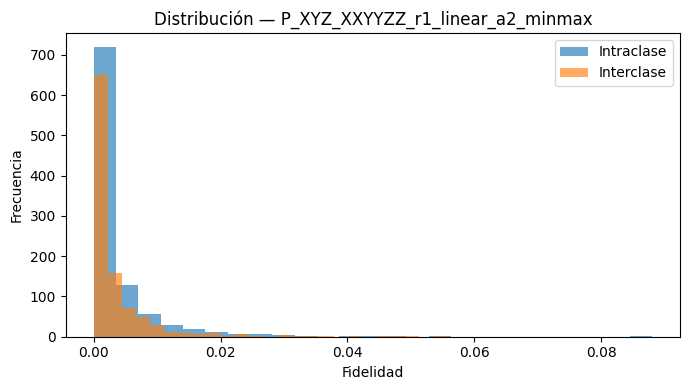

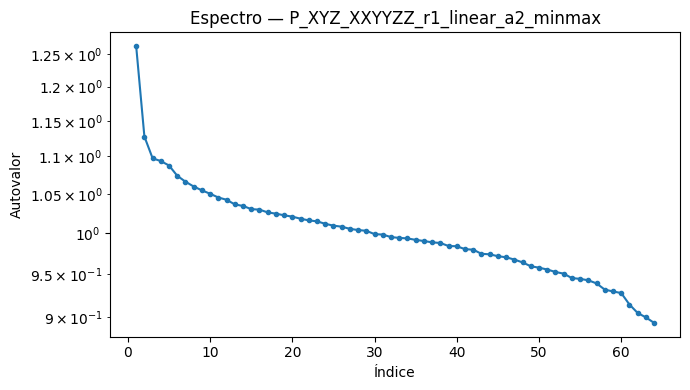

,map,group,global_alignment,global_intra_similarity,global_inter_similarity,global_similarity_gap,global_effective_rank,largest_eigenvalue,offdiag_mean,offdiag_std,distance_to_identity,distance_to_uniform,global_kernel_seconds
0,P_Z_r1_linear_a2_minmax,pauli_terms,0.135806,0.014461,0.010497,0.003964,60.824468,2.304246,0.012448,3.949684e-02,0.328697,9.805899e-01,0.084021
8,P_Z_ZZ_r2_linear_a2_minmax,reps,0.127700,0.003085,0.002618,0.000467,63.909035,1.216555,0.002848,6.141721e-03,0.053734,9.893499e-01,0.342697
6,P_XYZ_XXYYZZ_r1_linear_a2_minmax,pauli_terms,0.126796,0.003714,0.003471,0.000243,63.890670,1.261991,0.003590,6.530907e-03,0.059155,9.886157e-01,0.688004
13,P_Z_ZZ_r1_linear_a2_stdclip,scaling,0.126768,0.002823,0.002551,0.000271,63.831581,1.231798,0.002685,8.778690e-03,0.072865,9.895312e-01,0.348030
2,P_Z_ZZ_r1_linear_a2_minmax,baseline,0.126486,0.002465,0.002302,0.000164,63.910319,1.180530,0.002382,6.256119e-03,0.053135,9.898126e-01,0.171121
4,P_Y_YY_r1_linear_a2_minmax,pauli_terms,0.126486,0.002465,0.002302,0.000164,63.910319,1.180530,0.002382,6.256119e-03,0.053135,9.898126e-01,0.553207
14,P_Z_ZZ_r1_linear_a2_atan,scaling,0.126227,0.002239,0.002131,0.000108,63.893210,1.186416,0.002184,6.958953e-03,0.057892,9.900138e-01,0.179672
10,P_Z_ZZ_r1_full_a2_minmax,entanglement,0.126134,0.007209,0.007143,0.000066,63.839858,1.482892,0.007175,5.955730e-03,0.074014,9.850557e-01,0.458109
3,P_X_XX_r1_linear_a2_minmax,pauli_terms,0.125981,1.000000,1.000000,0.000000,1.000000,64.000000,1.000000,4.440892e-16,7.937254,1.674303e-14,0.519652
12,P_Z_ZZ_r1_linear_a4_minmax,alpha,0.125967,0.002029,0.002011,0.000017,63.945673,1.149333,0.002020,4.804710e-03,0.041369,9.901642e-01,1.030846


In [7]:

# 7. Kernel global descriptivo, mapa de calor, distribuciones y espectro
# El ajuste global de preprocesamiento en esta sección es solo descriptivo.
# Las métricas predictivas válidas son las obtenidas fold por fold arriba.
GLOBAL_KERNELS = {}
geometry_rows = []

maps_to_display = list(dict.fromkeys(
    [BASELINE_NAME] + summary.head(3)['map'].tolist()
))

for cfg in MAP_CONFIGS:
    feature_map = build_feature_map(cfg)
    preprocessor = AnglePreprocessor(cfg['scaling'])
    X_angles = preprocessor.fit_transform(X_raw)

    t0 = time.perf_counter()
    K = exact_kernel(feature_map, X_angles)
    elapsed = time.perf_counter() - t0
    GLOBAL_KERNELS[cfg['name']] = K

    intra, inter, gap = similarity_summary(K, y)
    effective_rank, eigenvalues = spectral_summary(K)
    concentration = kernel_concentration(K)
    geometry_rows.append({
        'map': cfg['name'],
        'group': cfg['group'],
        'global_alignment': centered_kernel_alignment(K, y),
        'global_intra_similarity': intra,
        'global_inter_similarity': inter,
        'global_similarity_gap': gap,
        'global_effective_rank': effective_rank,
        'largest_eigenvalue': float(eigenvalues.max()),
        **concentration,
        'global_kernel_seconds': elapsed,
    })

    order = np.argsort(y)
    plt.figure(figsize=(6.4, 5.4))
    plt.imshow(K[np.ix_(order, order)], interpolation='nearest', aspect='auto')
    plt.colorbar(label='Fidelidad')
    plt.title(cfg['name'])
    plt.xlabel('Muestras ordenadas por clase')
    plt.ylabel('Muestras ordenadas por clase')
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / f'heatmap_{cfg["name"]}.png', dpi=150)
    if cfg['name'] in maps_to_display:
        plt.show()
    else:
        plt.close()

    upper = np.triu_indices_from(K, k=1)
    same = y[upper[0]] == y[upper[1]]
    values = K[upper]
    plt.figure(figsize=(7, 4))
    plt.hist(values[same], bins=25, alpha=0.65, label='Intraclase')
    plt.hist(values[~same], bins=25, alpha=0.65, label='Interclase')
    plt.xlabel('Fidelidad')
    plt.ylabel('Frecuencia')
    plt.title(f'Distribución — {cfg["name"]}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / f'distribution_{cfg["name"]}.png', dpi=150)
    if cfg['name'] in maps_to_display:
        plt.show()
    else:
        plt.close()

    sorted_eigenvalues = np.sort(eigenvalues)[::-1]
    plt.figure(figsize=(7, 4))
    plt.plot(np.arange(1, len(sorted_eigenvalues) + 1), sorted_eigenvalues, marker='o', markersize=3)
    plt.yscale('log')
    plt.xlabel('Índice')
    plt.ylabel('Autovalor')
    plt.title(f'Espectro — {cfg["name"]}')
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / f'spectrum_{cfg["name"]}.png', dpi=150)
    if cfg['name'] in maps_to_display:
        plt.show()
    else:
        plt.close()

geometry_results = pd.DataFrame(geometry_rows).sort_values('global_alignment', ascending=False)
display(geometry_results)


In [8]:

# 8. Diagrama del mejor mapa exploratorio
best_map_name = summary.iloc[0]['map']
best_cfg = config_by_name[best_map_name]
best_feature_map = build_feature_map(best_cfg)

print('Mejor mapa exploratorio:', best_map_name)
print(best_cfg)
fig = best_feature_map.draw(output='mpl', fold=120)
fig.savefig(ARTIFACT_DIR / 'pauli_best_circuit.png', dpi=180, bbox_inches='tight')
plt.show()


Mejor mapa exploratorio: P_X_XX_r1_linear_a2_minmax
{'name': 'P_X_XX_r1_linear_a2_minmax', 'paulis': ('X', 'XX'), 'reps': 1, 'entanglement': 'linear', 'alpha': 2.0, 'scaling': 'minmax', 'group': 'pauli_terms'}


In [9]:

# 9. Recursos del circuito tras transpilación
BASIS_GATES = ['rz', 'sx', 'x', 'cx']
TOPOLOGIES = {
    'all_to_all': CouplingMap.from_full(NUM_QUBITS),
    'ring': CouplingMap.from_ring(NUM_QUBITS),
    'line': CouplingMap.from_line(NUM_QUBITS),
}

resource_rows = []
representative_raw = np.nanmedian(X_raw, axis=0, keepdims=True)

for cfg in MAP_CONFIGS:
    preprocessor = AnglePreprocessor(cfg['scaling']).fit(X_raw)
    representative = preprocessor.transform(representative_raw)[0]
    feature_map = build_feature_map(cfg)
    parameters = ordered_feature_parameters(feature_map)
    bound = feature_map.assign_parameters(dict(zip(parameters, representative)), inplace=False)

    for topology_name, coupling_map in TOPOLOGIES.items():
        t0 = time.perf_counter()
        pass_manager = generate_preset_pass_manager(
            optimization_level=1,
            basis_gates=BASIS_GATES,
            coupling_map=coupling_map,
            seed_transpiler=SEED,
        )
        physical = pass_manager.run(bound)
        elapsed = time.perf_counter() - t0
        counts = physical.count_ops()
        resource_rows.append({
            'map': cfg['name'],
            'group': cfg['group'],
            'topology': topology_name,
            'depth': int(physical.depth()),
            'cx_count': int(counts.get('cx', 0)),
            'total_gate_count': int(sum(counts.values())),
            'transpile_seconds': elapsed,
        })

resource_results = pd.DataFrame(resource_rows)
display(resource_results.sort_values(['map', 'topology']))


,map,group,topology,depth,cx_count,total_gate_count,transpile_seconds
18,P_XYZ_XXYYZZ_r1_linear_a2_minmax,pauli_terms,all_to_all,47,48,171,0.008651
20,P_XYZ_XXYYZZ_r1_linear_a2_minmax,pauli_terms,line,47,48,171,0.008754
19,P_XYZ_XXYYZZ_r1_linear_a2_minmax,pauli_terms,ring,47,48,171,0.007319
9,P_X_XX_r1_linear_a2_minmax,pauli_terms,all_to_all,28,16,60,0.007183
11,P_X_XX_r1_linear_a2_minmax,pauli_terms,line,28,16,60,0.006208
10,P_X_XX_r1_linear_a2_minmax,pauli_terms,ring,28,16,60,0.006972
15,P_X_Y_Z_r1_linear_a2_minmax,pauli_terms,all_to_all,5,0,45,0.010706
17,P_X_Y_Z_r1_linear_a2_minmax,pauli_terms,line,5,0,45,0.008379
16,P_X_Y_Z_r1_linear_a2_minmax,pauli_terms,ring,5,0,45,0.009361
12,P_Y_YY_r1_linear_a2_minmax,pauli_terms,all_to_all,30,16,78,0.007615



## Sensibilidad a shots

En un circuito de superposición `compute–uncompute`, cada entrada del kernel se estima como la frecuencia de medir $|0\cdots0\rangle$. Para aislar la variación estadística de los shots, se muestrea

$$
\widehat K_{ij}=\frac{\operatorname{Binomial}(N_{shots},K_{ij})}{N_{shots}}.
$$

Se estudian el mapa base y los tres mejores mapas exploratorios. El `C` se mantiene igual al seleccionado con el kernel exacto.


In [10]:

# 10. Sensibilidad a muestreo finito
def nearest_psd_correlation(K, epsilon=1e-10):
    K = (K + K.T) / 2.0
    eigenvalues, eigenvectors = np.linalg.eigh(K)
    eigenvalues = np.clip(eigenvalues, epsilon, None)
    projected = (eigenvectors * eigenvalues) @ eigenvectors.T
    diagonal = np.sqrt(np.clip(np.diag(projected), epsilon, None))
    projected = projected / np.outer(diagonal, diagonal)
    np.fill_diagonal(projected, 1.0)
    return np.clip(projected, 0.0, 1.0)


def sample_symmetric_kernel(K, shots, rng):
    n = len(K)
    sampled = np.eye(n)
    for i in range(n):
        for j in range(i + 1, n):
            value = rng.binomial(shots, np.clip(K[i, j], 0.0, 1.0)) / shots
            sampled[i, j] = sampled[j, i] = value
    return nearest_psd_correlation(sampled)


def sample_rectangular_kernel(K, shots, rng):
    return rng.binomial(shots, np.clip(K, 0.0, 1.0)) / shots

selected_shot_maps = list(dict.fromkeys([BASELINE_NAME] + summary.head(3)['map'].tolist()))
shot_rows = []

if RUN_SHOT_STUDY:
    for map_number, map_name in enumerate(selected_shot_maps):
        for shots in SHOT_LEVELS:
            for repeat in range(SHOT_REPEATS):
                rng = np.random.default_rng(SEED + map_number * 100000 + shots * 10 + repeat)
                for fold, item in KERNEL_CACHE[map_name].items():
                    sampled_train = sample_symmetric_kernel(item['K_train'], shots, rng)
                    sampled_validation = sample_rectangular_kernel(item['K_validation'], shots, rng)
                    classifier = SVC(kernel='precomputed', C=item['C'])
                    classifier.fit(sampled_train, item['y_train'])
                    prediction = classifier.predict(sampled_validation)
                    metrics = binary_metrics(item['y_validation'], prediction)
                    metrics.update({
                        'map': map_name,
                        'shots': int(shots),
                        'repeat': int(repeat),
                        'fold': int(fold),
                        'relative_kernel_error': float(
                            np.linalg.norm(sampled_train - item['K_train'], 'fro') /
                            np.linalg.norm(item['K_train'], 'fro')
                        ),
                    })
                    shot_rows.append(metrics)

shot_results = pd.DataFrame(shot_rows)
if not shot_results.empty:
    shot_summary = (
        shot_results.groupby(['map', 'shots'])[
            ['accuracy', 'balanced_accuracy', 'f1', 'relative_kernel_error']
        ].agg(['mean', 'std']).reset_index()
    )
    shot_summary.columns = [
        '_'.join(column).rstrip('_') if isinstance(column, tuple) else column
        for column in shot_summary.columns
    ]
    display(shot_summary)


,map,shots,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,relative_kernel_error_mean,relative_kernel_error_std
0,P_XYZ_XXYYZZ_r1_linear_a2_minmax,128,0.537500,0.124009,0.537500,0.124009,0.545039,0.138103,3.590768e-02,0.001097
1,P_XYZ_XXYYZZ_r1_linear_a2_minmax,512,0.571875,0.097828,0.571875,0.097828,0.582732,0.098444,1.796032e-02,0.000844
2,P_XYZ_XXYYZZ_r1_linear_a2_minmax,2048,0.559375,0.077149,0.559375,0.077149,0.574420,0.076895,9.062228e-03,0.000466
3,P_X_XX_r1_linear_a2_minmax,128,0.500000,0.000000,0.500000,0.000000,0.666667,0.000000,9.893616e-11,0.000000
4,P_X_XX_r1_linear_a2_minmax,512,0.500000,0.000000,0.500000,0.000000,0.666667,0.000000,9.893616e-11,0.000000
5,P_X_XX_r1_linear_a2_minmax,2048,0.500000,0.000000,0.500000,0.000000,0.666667,0.000000,9.893616e-11,0.000000
6,P_Z_ZZ_r1_linear_a2_minmax,128,0.500000,0.111065,0.500000,0.111065,0.459638,0.188279,2.846120e-02,0.001847
7,P_Z_ZZ_r1_linear_a2_minmax,512,0.559375,0.089486,0.559375,0.089486,0.537652,0.125544,1.489163e-02,0.000892
8,P_Z_ZZ_r1_linear_a2_minmax,2048,0.550000,0.102598,0.550000,0.102598,0.536397,0.161649,7.278395e-03,0.000342
9,P_Z_r1_linear_a2_minmax,128,0.590625,0.068690,0.590625,0.068690,0.627718,0.062492,5.592306e-02,0.004563



## Sensibilidad a ruido

Se simulan circuitos explícitos `compute–uncompute` con ruido despolarizante:

- leve: $p_1=0.001$, $p_2=0.01$;
- moderado: $p_1=0.003$, $p_2=0.03$.

Para controlar el costo, se evalúan pares intra e interclase del mapa base y del mejor mapa exploratorio. Esta sección es diagnóstica y no interviene en la selección del clasificador.


In [11]:

# 11. Ruido despolarizante sobre pares representativos
def make_noise_model(p1, p2):
    model = NoiseModel()
    model.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ['sx', 'x'])
    model.add_all_qubit_quantum_error(depolarizing_error(p2, 2), ['cx'])
    return model


def overlap_circuit(feature_map, x_i, x_j):
    parameters = ordered_feature_parameters(feature_map)
    U_i = feature_map.assign_parameters(dict(zip(parameters, x_i)), inplace=False)
    U_j = feature_map.assign_parameters(dict(zip(parameters, x_j)), inplace=False)
    circuit = QuantumCircuit(NUM_QUBITS, NUM_QUBITS)
    circuit.compose(U_i, inplace=True)
    circuit.compose(U_j.inverse(), inplace=True)
    circuit.measure(range(NUM_QUBITS), range(NUM_QUBITS))
    return circuit


def noisy_overlap(feature_map, x_i, x_j, noise_model, shots, seed):
    backend = AerSimulator(noise_model=noise_model)
    pass_manager = generate_preset_pass_manager(
        optimization_level=1,
        backend=backend,
        seed_transpiler=seed,
    )
    physical = pass_manager.run(overlap_circuit(feature_map, x_i, x_j))
    result = backend.run(physical, shots=shots, seed_simulator=seed).result()
    counts = result.get_counts()
    return counts.get('0' * NUM_QUBITS, 0) / shots


def representative_pairs(labels, n_pairs, seed):
    rng = np.random.default_rng(seed)
    all_pairs = [(i, j) for i in range(len(labels)) for j in range(i + 1, len(labels))]
    intra = [(i, j) for i, j in all_pairs if labels[i] == labels[j]]
    inter = [(i, j) for i, j in all_pairs if labels[i] != labels[j]]
    half = n_pairs // 2
    selected_intra = [intra[k] for k in rng.choice(len(intra), size=half, replace=False)]
    selected_inter = [inter[k] for k in rng.choice(len(inter), size=n_pairs - half, replace=False)]
    return selected_intra + selected_inter

noise_levels = {
    'mild': (0.001, 0.01),
    'moderate': (0.003, 0.03),
}
selected_noise_maps = list(dict.fromkeys([BASELINE_NAME, best_map_name]))
noise_rows = []

if RUN_NOISE_STUDY:
    for map_number, map_name in enumerate(selected_noise_maps):
        print('Noise:', map_name)
        cfg = config_by_name[map_name]
        feature_map = build_feature_map(cfg)
        preprocessor = AnglePreprocessor(cfg['scaling']).fit(X_raw)
        X_angles = preprocessor.transform(X_raw)
        K_exact = GLOBAL_KERNELS[map_name]
        pairs = representative_pairs(y, NOISE_PAIRS_PER_MAP, SEED + map_number)

        for level, (p1, p2) in noise_levels.items():
            noise_model = make_noise_model(p1, p2)
            for pair_number, (i, j) in enumerate(pairs):
                t0 = time.perf_counter()
                estimate = noisy_overlap(
                    feature_map, X_angles[i], X_angles[j], noise_model,
                    NOISE_SHOTS, SEED + map_number * 1000 + pair_number,
                )
                elapsed = time.perf_counter() - t0
                noise_rows.append({
                    'map': map_name,
                    'noise_level': level,
                    'i': int(i),
                    'j': int(j),
                    'pair_type': 'intra' if y[i] == y[j] else 'inter',
                    'exact_kernel': float(K_exact[i, j]),
                    'noisy_kernel': float(estimate),
                    'absolute_error': float(abs(estimate - K_exact[i, j])),
                    'simulation_seconds': elapsed,
                })

noise_results = pd.DataFrame(noise_rows)
if not noise_results.empty:
    noise_summary = (
        noise_results.groupby(['map', 'noise_level'])
        .agg(
            mean_absolute_error=('absolute_error', 'mean'),
            exact_mean=('exact_kernel', 'mean'),
            noisy_mean=('noisy_kernel', 'mean'),
            simulation_seconds=('simulation_seconds', 'sum'),
        )
        .reset_index()
    )
    display(noise_summary)


Noise: P_Z_ZZ_r1_linear_a2_minmax
Noise: P_X_XX_r1_linear_a2_minmax


,map,noise_level,mean_absolute_error,exact_mean,noisy_mean,simulation_seconds
0,P_X_XX_r1_linear_a2_minmax,mild,0.192139,1.000000,0.807861,1.962479
1,P_X_XX_r1_linear_a2_minmax,moderate,0.470459,1.000000,0.529541,1.977002
2,P_Z_ZZ_r1_linear_a2_minmax,mild,0.001171,0.001621,0.001465,3.434674
3,P_Z_ZZ_r1_linear_a2_minmax,moderate,0.001260,0.001621,0.000977,4.280676


,group,maps,best_f1,mean_f1,best_balanced_accuracy,mean_alignment,mean_total_seconds
3,pauli_terms,7,0.666667,0.586786,0.609375,0.145911,1.089142
5,scaling,2,0.519697,0.496305,0.515625,0.145895,0.182958
4,reps,1,0.511813,0.511813,0.562500,0.146614,0.881958
0,alpha,2,0.510719,0.441975,0.515625,0.145025,0.182523
1,baseline,1,0.489477,0.489477,0.531250,0.145575,0.472023
2,entanglement,2,0.459955,0.454470,0.500000,0.145873,0.446300


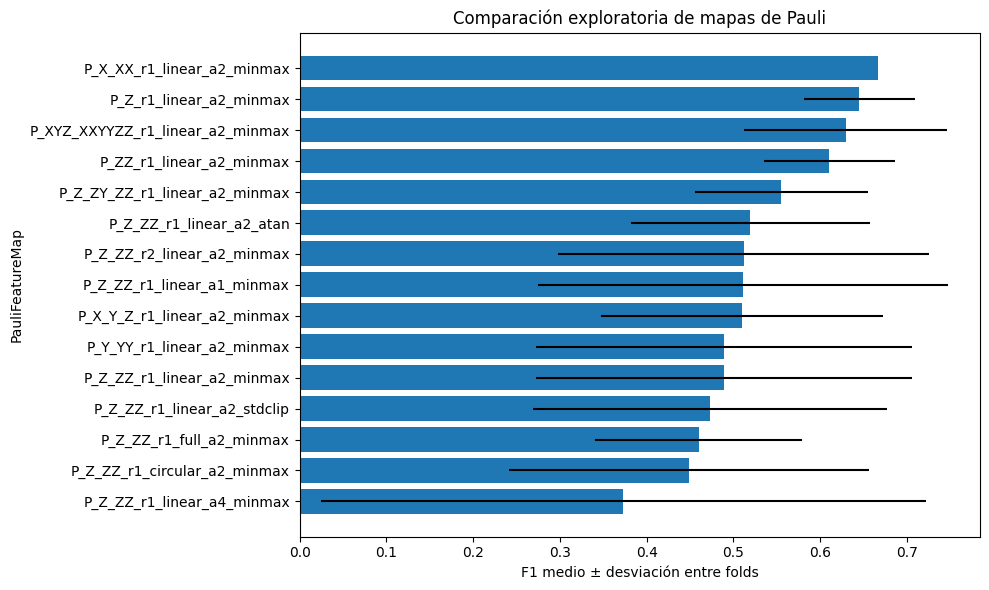

In [12]:

# 12. Resumen por tipo de ablación
ablation_summary = (
    summary.groupby('group')
    .agg(
        maps=('map', 'count'),
        best_f1=('f1_mean', 'max'),
        mean_f1=('f1_mean', 'mean'),
        best_balanced_accuracy=('balanced_accuracy_mean', 'max'),
        mean_alignment=('alignment_mean', 'mean'),
        mean_total_seconds=('total_seconds_mean', 'mean'),
    )
    .reset_index()
    .sort_values('best_f1', ascending=False)
)
display(ablation_summary)

plt.figure(figsize=(10, 6))
plot_data = summary.sort_values('f1_mean')
plt.barh(plot_data['map'], plot_data['f1_mean'], xerr=plot_data['f1_std'])
plt.xlabel('F1 medio ± desviación entre folds')
plt.ylabel('PauliFeatureMap')
plt.title('Comparación exploratoria de mapas de Pauli')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'pauli_f1_comparison.png', dpi=180)
plt.show()


In [13]:

# 13. Exportación y manifiesto reproducible
fold_results.to_csv(ARTIFACT_DIR / 'pauli_fold_metrics.csv', index=False)
summary.to_csv(ARTIFACT_DIR / 'pauli_cv_summary.csv', index=False)
geometry_results.to_csv(ARTIFACT_DIR / 'pauli_geometry.csv', index=False)
resource_results.to_csv(ARTIFACT_DIR / 'pauli_circuit_resources.csv', index=False)
ablation_summary.to_csv(ARTIFACT_DIR / 'pauli_ablation_summary.csv', index=False)

if not shot_results.empty:
    shot_results.to_csv(ARTIFACT_DIR / 'pauli_shot_sensitivity.csv', index=False)
if not noise_results.empty:
    noise_results.to_csv(ARTIFACT_DIR / 'pauli_noise_sensitivity.csv', index=False)

np.savez_compressed(
    ARTIFACT_DIR / 'pauli_global_kernels.npz',
    **{name: matrix for name, matrix in GLOBAL_KERNELS.items()}
)

best_row = summary.iloc[0].to_dict()
manifest = {
    'notebook': 'V06_Challenge2_PauliFeatureMap_Study.ipynb',
    'sdk': 'Qiskit',
    'qiskit_version': '2.2.3',
    'qiskit_aer_version': '0.17.2',
    'feature_map_constructor': 'qiskit.circuit.library.pauli_feature_map',
    'seed': SEED,
    'num_samples': 64,
    'num_features': len(FEATURES),
    'num_qubits': NUM_QUBITS,
    'state_dimension': 2 ** NUM_QUBITS,
    'folds': 4,
    'outer_train_size': 48,
    'outer_validation_size': 16,
    'svc_kernel': 'precomputed',
    'kernel_definition': '|<phi(x_i)|phi(x_j)>|^2',
    'c_grid': list(C_GRID),
    'map_configs': MAP_CONFIGS,
    'best_exploratory_map': best_row.get('map'),
    'best_exploratory_mean_f1': best_row.get('f1_mean'),
    'selection_warning': 'Ranking exploratorio; múltiples mapas fueron comparados sobre los mismos folds.',
    'quick_mode': QUICK_MODE,
    'shot_study': RUN_SHOT_STUDY,
    'noise_study': RUN_NOISE_STUDY,
    'data_file': str(raw_path),
    'fold_file': str(fold_path),
}
with open(ARTIFACT_DIR / 'pauli_manifest.json', 'w', encoding='utf-8') as file:
    json.dump(manifest, file, indent=2, ensure_ascii=False)

checks = pd.DataFrame([
    {'check': '64 real samples', 'passed': len(raw64) == 64},
    {'check': 'balanced labels 32/32', 'passed': raw64[TARGET].value_counts().to_dict() == {0: 32, 1: 32}},
    {'check': 'four frozen folds', 'passed': set(validation_fold) == {0, 1, 2, 3}},
    {'check': 'nine features equal nine qubits', 'passed': len(FEATURES) == NUM_QUBITS},
    {'check': 'only pauli_feature_map family studied', 'passed': True},
    {'check': 'SVC uses precomputed kernels', 'passed': True},
    {'check': 'preprocessing fit inside each outer fold', 'passed': True},
    {'check': 'C selected only inside outer training', 'passed': True},
])
checks.to_csv(ARTIFACT_DIR / 'pauli_checks.csv', index=False)
display(checks)

print('Mejor configuración exploratoria:')
display(summary.head(1))
print('Archivos exportados en:', ARTIFACT_DIR)


,check,passed
0,64 real samples,True
1,balanced labels 32/32,True
2,four frozen folds,True
3,nine features equal nine qubits,True
4,only pauli_feature_map family studied,True
5,SVC uses precomputed kernels,True
6,preprocessing fit inside each outer fold,True
7,C selected only inside outer training,True


Mejor configuración exploratoria:


,map,group,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,precision_mean,precision_std,...,offdiag_mean_mean,offdiag_mean_std,offdiag_std_mean,offdiag_std_std,distance_to_identity_mean,distance_to_identity_std,distance_to_uniform_mean,distance_to_uniform_std,total_seconds_mean,total_seconds_std
1,P_X_XX_r1_linear_a2_minmax,pauli_terms,0.5,0.0,0.5,0.0,0.666667,0.0,0.5,0.0,...,1.0,0.0,1.110223e-16,0.0,6.855655,0.0,1.669868e-14,0.0,1.582922,0.303611


Archivos exportados en: /content/drive/MyDrive/Colab Notebooks/artifacts_pauli_feature_map_v1



## Guía de interpretación

- **Kernel casi identidad:** fidelidades fuera de la diagonal cercanas a cero. El mapa memoriza diferencias entre observaciones y puede generalizar poco.
- **Kernel casi uniforme:** fidelidades similares y altas para casi todos los pares. El SVC recibe poca información discriminativa.
- **Geometría favorable:** la similitud intraclase supera a la interclase, la alineación kernel–objetivo es positiva y el espectro conserva varias direcciones útiles sin dispersarse por completo.
- **Mayor expresividad no implica mayor F1:** añadir `X`, `Y`, más términos de dos qubits, más repeticiones o entrelazamiento completo puede aumentar profundidad y ruido sin mejorar la estructura de clases.
- **Shots y ruido:** deben analizarse junto con profundidad y número de `CX`, porque dos mapas con rendimiento exacto parecido pueden tener viabilidad física muy distinta.

La tabla principal para el estudio es `pauli_cv_summary.csv`. Los mapas de calor, distribuciones, espectros y recursos explican los mecanismos detrás de sus resultados.
